# PRÁCTICA 3 SEMANA 1

**Se recomienda ejecutar los códigos de este jupyer notebook en la misma carpeta donde reside dicho documento, debido a la dependencia de ciertos documentos para el correcto uso del mismo.**

En primer lugar, vamos a importar las librerías necesarias y vamos a importar los csv necesarios.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import (
    MultinomialNB,
    GaussianNB,
    CategoricalNB
)
from sklearn.metrics import (
    r2_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    accuracy_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.api import Logit

# Utilidades generales
import warnings
warnings.filterwarnings("ignore")


In [30]:
explotacion = pd.read_csv("fuga_clientes_empresa_telefonica_explotacion.csv")
construccion = pd.read_csv("fuga_clientes_empresa_telefonica_construccion.csv")

En esta semana 1 vamos a centrarnos en la limpieza y la creación de un modelo dummy y un modelo de regresión lineal con sklearn completando la información con las prácticas de semanas anteriores. Tenemos que especificar que el dataframe de entrenamiento es construcción y el de testeo es el de expliotación, ya que el de explotación en la variable a predecir tiene valores Nan.

In [31]:
explotacion

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 1,Network type subscription in Month 2,Most Loved Competitor network in Month 1,Most Loved Competitor network in Month 2,Churn Status
0,ADF0038,1785,59.50,960.5568,35.25,353.75,4.871259e+05,73,2954,13313,4,Other,Other,Uxaa,Uxaa,NaN
1,ADF0042,1330,44.33,60.5036,0.03,32.50,9.527231e+06,14,36,1876,2,NaN,NaN,PQza,PQza,NaN
2,ADF0065,112,3.73,418.4264,0.00,95.00,2.779944e+06,43,672,3713,2,NaN,NaN,Uxaa,Uxaa,NaN
3,ADF0081,351,11.70,893.5700,0.60,0.00,4.149374e+06,405,0,563,3,NaN,3G,ToCall,Uxaa,NaN
4,ADF0098,1492,49.73,1061.8480,14.64,0.00,7.721029e+04,430,6642,713,2,Other,Other,PQza,Uxaa,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,ADF1978,1268,42.27,898.3100,137.65,5.00,1.314570e+02,84,26304,27511,1,NaN,NaN,PQza,Uxaa,NaN
285,ADF1979,115,3.83,298.5780,0.00,5.27,2.368606e+06,14,847,228,4,NaN,3G,ToCall,Uxaa,NaN
286,ADF1982,4190,139.67,967.0904,25.37,115.00,2.829380e+07,36,1235,9209,1,NaN,NaN,ToCall,Uxaa,NaN
287,ADF1985,112,3.73,962.8800,382.37,20.00,4.652655e+05,187,6132,755,1,NaN,3G,ToCall,Uxaa,NaN


In [32]:
construccion

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 1,Network type subscription in Month 2,Most Loved Competitor network in Month 1,Most Loved Competitor network in Month 2,Churn Status
0,ADF0039,1345,44.83,963.0800,0.00,0.00,1.473830e+01,788,2940,1458,4,2G,2G,Weematel,Uxaa,0
1,ADF0040,2713,90.43,5979.4120,48.38,505.00,8.344973e+07,1127,0,58255,2,3G,3G,Uxaa,Uxaa,0
2,ADF0041,746,24.87,114.9000,14.94,13.75,7.115992e+04,15,131,2978,1,3G,3G,PQza,PQza,1
3,ADF0043,1967,65.57,54.1000,8.75,0.00,1.839360e+01,70,696,2274,1,3G,2G,PQza,PQza,1
4,ADF0044,2576,85.87,1222.2204,41.85,131.25,3.537593e+05,98,18635,34804,3,2G,2G,ToCall,Uxaa,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,ADF1996,3836,127.87,24438.8300,664.92,8295.00,1.737079e+06,678,72120,337192,10,3G,3G,ToCall,Weematel,1
1107,ADF1997,105,3.50,75.4000,10.50,10.00,2.401224e+06,22,2532,1522,2,2G,3G,Uxaa,PQza,1
1108,ADF1998,2172,72.40,16.6420,0.00,8.75,1.312746e+05,5,0,203,2,2G,2G,PQza,PQza,1
1109,ADF1999,2774,92.47,652.6300,4.14,57.50,2.166006e+06,526,741,716,1,3G,3G,Weematel,Uxaa,0


#### PRIMERA PARTE
En primer lugar, vamos a centrarnos en la limpieza de los dos datasets. Para ello, vamos a centrarnos primeramente en eliminar las variables colineales, redefiniendo los datasets sin la variable target(Churn Status), ya que es la variable a predecir y es la variable más dependiente. Después vamos a eliminar los outliers y por último redefinir las variables si hicieran falta en caso de que halla valores nulos o outliers.

In [33]:
# Utilizamos str.extract para eliminar los strings de la id para que no nos de problema
explotacion["Customer ID"] = explotacion["Customer ID"].str.extract(r"(\d+)")
explotacion["Customer ID"] = explotacion["Customer ID"].astype(int)
construccion["Customer ID"] = construccion["Customer ID"].str.extract(r"(\d+)")
construccion["Customer ID"] = construccion["Customer ID"].astype(int)

In [34]:
explotacion_mod = explotacion.drop(columns=["Churn Status"])
construccion_mod = construccion.drop(columns=["Churn Status"])

Redefinimos el ID. Desarrollamos las columnas de network y most usando get_dummies, ya que son variables categóricas para calcular la covarianza. Con la matriz de covarianza podremos hallar su rango y por tanto las variables colineales. Hacemos lo mismo para los dos dataframes. Pero antes vamos a concatenar ambos dataframes para que se eliminen las mismas variables en ambos dataframes. Es una medida de seguridad

In [35]:

# Añadimos un identificador temporal para poder separar después del get_dummies
explotacion_mod['_dataset'] = 'explotacion'
construccion_mod['_dataset'] = 'construccion'

# Concatenamos los dataframes
combined = pd.concat([construccion_mod, explotacion_mod], axis=0, ignore_index=True)

# Aplicar get_dummies a todo el dataset concatenado
# Así se crean las mismas columnas para ambos datasets
combined = pd.get_dummies(combined, columns=["Network type subscription in Month 1"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Network type subscription in Month 2"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Most Loved Competitor network in Month 1"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Most Loved Competitor network in Month 2"], drop_first=True)

# Separamos de nuevo en construccion y explotacion
construccion_mod = combined[combined['_dataset'] == 'construccion'].copy()
explotacion_mod = combined[combined['_dataset'] == 'explotacion'].copy()

# Eliminamos el identificador temporal
construccion_mod = construccion_mod.drop(columns=['_dataset'])
explotacion_mod = explotacion_mod.drop(columns=['_dataset'])

# Verificar que ahora tienen el mismo número de columnas
print(f"Construcción: {construccion_mod.shape[1]} columnas")
print(f"Explotación: {explotacion_mod.shape[1]} columnas")

# Calculamos matrices de covarianza
cov_construccion = construccion_mod.cov()
cov_explotacion = explotacion_mod.cov()


Construcción: 26 columnas
Explotación: 26 columnas


In [36]:
explotacion_mod

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,...,Most Loved Competitor network in Month 1_PQza,Most Loved Competitor network in Month 1_ToCall,Most Loved Competitor network in Month 1_Uxaa,Most Loved Competitor network in Month 1_Weematel,Most Loved Competitor network in Month 1_Zintel,Most Loved Competitor network in Month 2_PQza,Most Loved Competitor network in Month 2_ToCall,Most Loved Competitor network in Month 2_Uxaa,Most Loved Competitor network in Month 2_Weematel,Most Loved Competitor network in Month 2_Zintel
1111,38,1785,59.50,960.5568,35.25,353.75,4.871259e+05,73,2954,13313,...,False,False,True,False,False,False,False,True,False,False
1112,42,1330,44.33,60.5036,0.03,32.50,9.527231e+06,14,36,1876,...,True,False,False,False,False,True,False,False,False,False
1113,65,112,3.73,418.4264,0.00,95.00,2.779944e+06,43,672,3713,...,False,False,True,False,False,False,False,True,False,False
1114,81,351,11.70,893.5700,0.60,0.00,4.149374e+06,405,0,563,...,False,True,False,False,False,False,False,True,False,False
1115,98,1492,49.73,1061.8480,14.64,0.00,7.721029e+04,430,6642,713,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,1978,1268,42.27,898.3100,137.65,5.00,1.314570e+02,84,26304,27511,...,True,False,False,False,False,False,False,True,False,False
1396,1979,115,3.83,298.5780,0.00,5.27,2.368606e+06,14,847,228,...,False,True,False,False,False,False,False,True,False,False
1397,1982,4190,139.67,967.0904,25.37,115.00,2.829380e+07,36,1235,9209,...,False,True,False,False,False,False,False,True,False,False
1398,1985,112,3.73,962.8800,382.37,20.00,4.652655e+05,187,6132,755,...,False,True,False,False,False,False,False,True,False,False


In [37]:
construccion_mod

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,...,Most Loved Competitor network in Month 1_PQza,Most Loved Competitor network in Month 1_ToCall,Most Loved Competitor network in Month 1_Uxaa,Most Loved Competitor network in Month 1_Weematel,Most Loved Competitor network in Month 1_Zintel,Most Loved Competitor network in Month 2_PQza,Most Loved Competitor network in Month 2_ToCall,Most Loved Competitor network in Month 2_Uxaa,Most Loved Competitor network in Month 2_Weematel,Most Loved Competitor network in Month 2_Zintel
0,39,1345,44.83,963.0800,0.00,0.00,1.473830e+01,788,2940,1458,...,False,False,False,True,False,False,False,True,False,False
1,40,2713,90.43,5979.4120,48.38,505.00,8.344973e+07,1127,0,58255,...,False,False,True,False,False,False,False,True,False,False
2,41,746,24.87,114.9000,14.94,13.75,7.115992e+04,15,131,2978,...,True,False,False,False,False,True,False,False,False,False
3,43,1967,65.57,54.1000,8.75,0.00,1.839360e+01,70,696,2274,...,True,False,False,False,False,True,False,False,False,False
4,44,2576,85.87,1222.2204,41.85,131.25,3.537593e+05,98,18635,34804,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,1996,3836,127.87,24438.8300,664.92,8295.00,1.737079e+06,678,72120,337192,...,False,True,False,False,False,False,False,False,True,False
1107,1997,105,3.50,75.4000,10.50,10.00,2.401224e+06,22,2532,1522,...,False,False,True,False,False,True,False,False,False,False
1108,1998,2172,72.40,16.6420,0.00,8.75,1.312746e+05,5,0,203,...,True,False,False,False,False,True,False,False,False,False
1109,1999,2774,92.47,652.6300,4.14,57.50,2.166006e+06,526,741,716,...,False,False,False,True,False,False,False,True,False,False


In [38]:
cov_explotacion

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,...,Most Loved Competitor network in Month 1_PQza,Most Loved Competitor network in Month 1_ToCall,Most Loved Competitor network in Month 1_Uxaa,Most Loved Competitor network in Month 1_Weematel,Most Loved Competitor network in Month 1_Zintel,Most Loved Competitor network in Month 2_PQza,Most Loved Competitor network in Month 2_ToCall,Most Loved Competitor network in Month 2_Uxaa,Most Loved Competitor network in Month 2_Weematel,Most Loved Competitor network in Month 2_Zintel
Customer ID,2.903626e+05,3.940865e+04,1.313765e+03,-5.575626e+03,-1.350334e+02,-5.808971e+02,-6.526912e+07,7.439581e+02,-1.264468e+05,7.466517e+04,...,-13.261366,10.699527,1.393070,10.915177,-8.744065,-23.176326,-0.890703,24.801158,-8.518214,-1.548395
network_age,3.940865e+04,1.604282e+06,5.347614e+04,2.495161e+05,-5.223817e+03,-9.819098e+02,-2.022039e+08,9.846907e+04,1.768205e+06,7.375808e+06,...,22.263276,13.559232,-15.986928,22.196691,-17.984477,-57.817198,-17.774510,102.776961,12.373570,-30.592116
Customer tenure in month,1.313765e+03,5.347614e+04,1.782540e+03,8.317151e+03,-1.741236e+02,-3.271795e+01,-6.740377e+06,3.282281e+03,5.893711e+04,2.458600e+05,...,0.742135,0.451867,-0.532836,0.739855,-0.599472,-1.927245,-0.592506,3.425903,0.412416,-1.019699
Total Spend in Months 1 and 2 of 2017,-5.575626e+03,2.495161e+05,8.317151e+03,9.073748e+05,6.138769e+03,8.645495e+03,-5.200512e+07,2.005310e+05,2.021865e+07,3.046482e+07,...,-32.677262,24.177786,-56.954327,4.443767,68.256409,-72.148020,-12.121349,74.422332,21.727012,-15.446374
Total SMS Spend,-1.350334e+02,-5.223817e+03,-1.741236e+02,6.138769e+03,4.768201e+03,-3.558224e+01,-2.053083e+07,-6.055085e+02,8.898215e+04,9.784188e+04,...,-2.053696,1.202140,0.207751,0.413490,0.078263,-1.985199,-0.025324,2.923909,-0.649006,-0.568152
Total Data Spend,-5.808971e+02,-9.819098e+02,-3.271795e+01,8.645495e+03,-3.558224e+01,2.485326e+03,5.845256e+07,-1.239489e+03,4.831371e+04,2.551868e+05,...,2.251526,0.425125,-1.860921,-0.293171,0.122389,1.843208,-0.291753,-2.255680,0.692805,-0.755239
Total Data Consumption,-6.526912e+07,-2.022039e+08,-6.740377e+06,-5.200512e+07,-2.053083e+07,5.845256e+07,2.070569e+13,-1.377552e+08,-9.888944e+09,-7.603158e+09,...,108512.149878,18173.619699,-241359.446132,111.523757,141746.882909,154693.477253,11826.987897,-167386.180342,-13101.899535,-55272.001238
Total Unique Calls,7.439581e+02,9.846907e+04,3.282281e+03,2.005310e+05,-6.055085e+02,-1.239489e+03,-1.377552e+08,9.584143e+04,3.123474e+06,5.069673e+06,...,-9.446823,-2.562728,-6.686383,7.367178,14.862757,-30.557658,-6.118032,42.478650,1.643959,-5.451990
Total Onnet spend,-1.264468e+05,1.768205e+06,5.893711e+04,2.021865e+07,8.898215e+04,4.831371e+04,-9.888944e+09,3.123474e+06,7.935695e+08,8.273320e+08,...,-421.612216,365.505611,-855.061455,-512.069817,1408.728914,-1455.957276,-333.390210,1721.323553,345.877391,-258.998210
Total Offnet spend,7.466517e+04,7.375808e+06,2.458600e+05,3.046482e+07,9.784188e+04,2.551868e+05,-7.603158e+09,5.069673e+06,8.273320e+08,1.468858e+09,...,-1044.344002,789.790117,-1865.853890,-340.814434,2868.216768,-1576.317090,-168.364055,-707.410671,1295.983071,277.070117


In [39]:
cov_construccion

,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,...,Most Loved Competitor network in Month 1_PQza,Most Loved Competitor network in Month 1_ToCall,Most Loved Competitor network in Month 1_Uxaa,Most Loved Competitor network in Month 1_Weematel,Most Loved Competitor network in Month 1_Zintel,Most Loved Competitor network in Month 2_PQza,Most Loved Competitor network in Month 2_ToCall,Most Loved Competitor network in Month 2_Uxaa,Most Loved Competitor network in Month 2_Weematel,Most Loved Competitor network in Month 2_Zintel
Customer ID,3.507546e+05,1.741905e+04,5.805463e+02,1.219702e+04,1.173675e+03,3.534200e+03,-6.290199e+07,5.559683e+03,-1.211012e+05,4.721670e+05,...,-3.651054,-6.121198,11.545422,-2.482664,-3.756846,-12.309304,-0.423946,10.743619,-5.017141,-0.862223
network_age,1.741905e+04,1.617158e+06,5.390510e+04,2.107473e+05,-2.820124e+03,1.719833e+04,-6.696182e+08,8.476756e+04,1.649648e+05,3.423432e+06,...,-32.748795,9.305101,-8.039435,27.147024,-5.703042,-69.959991,-12.927049,120.548405,1.089444,-13.199248
Customer tenure in month,5.805463e+02,5.390510e+04,1.796832e+03,7.024897e+03,-9.400257e+01,5.733045e+02,-2.232024e+07,2.825607e+03,5.498740e+03,1.141174e+05,...,-1.091590,0.310152,-0.267994,0.904944,-0.190105,-2.331956,-0.430891,4.018259,0.036315,-0.439980
Total Spend in Months 1 and 2 of 2017,1.219702e+04,2.107473e+05,7.024897e+03,1.735279e+06,3.608104e+04,3.011032e+05,1.256507e+09,2.228065e+05,6.720800e+06,3.605940e+07,...,-63.743811,33.197607,-17.078615,20.089761,13.421819,-123.584296,-4.333164,85.197902,46.350765,1.892176
Total SMS Spend,1.173675e+03,-2.820124e+03,-9.400257e+01,3.608104e+04,3.434653e+03,7.888634e+03,-1.579286e+07,1.943193e+03,2.335999e+05,7.636826e+05,...,-0.177923,0.678068,-0.164765,0.093385,-0.511510,-0.745831,0.030016,-0.888175,1.690281,0.094862
Total Data Spend,3.534200e+03,1.719833e+04,5.733045e+02,3.011032e+05,7.888634e+03,1.046994e+05,2.122883e+08,1.227771e+04,1.012424e+06,4.094290e+06,...,-2.821411,5.842608,-5.137651,1.809026,0.004206,-7.997610,-1.379102,1.634730,8.857001,-0.134801
Total Data Consumption,-6.290199e+07,-6.696182e+08,-2.232024e+07,1.256507e+09,-1.579286e+07,2.122883e+08,5.388655e+13,1.558238e+07,-5.257416e+09,2.874284e+09,...,39745.269257,-128632.465276,33580.091708,-63927.736436,33395.119408,-16260.070801,-8898.016112,-210.299594,5989.873733,77532.966504
Total Unique Calls,5.559683e+03,8.476756e+04,2.825607e+03,2.228065e+05,1.943193e+03,1.227771e+04,1.558238e+07,9.010957e+04,9.961473e+05,6.071908e+06,...,-17.324910,9.018166,-6.665175,8.105981,2.712211,-37.230239,-3.745720,47.590510,2.108780,-2.067227
Total Onnet spend,-1.211012e+05,1.649648e+05,5.498740e+03,6.720800e+06,2.335999e+05,1.012424e+06,-5.257416e+09,9.961473e+05,1.431759e+08,1.725928e+08,...,-648.808748,448.969663,27.728440,139.276148,-101.228320,-1053.148424,14.886560,1082.734723,67.475785,-42.591422
Total Offnet spend,4.721670e+05,3.423432e+06,1.141174e+05,3.605940e+07,7.636826e+05,4.094290e+06,2.874284e+09,6.071908e+06,1.725928e+08,1.385093e+09,...,-1595.334006,773.735330,-596.906111,603.976138,23.882294,-2744.156379,578.509406,-475.862371,1409.220271,232.783055


Para eliminar las variables colineales vamos a hallar las matrices de covarianza y sus rangos. Con ello podremos ver cuantas variables dependientes o colineales hay.

In [40]:
rango_construccion = np.linalg.matrix_rank(cov_construccion)
rango_explotacion = np.linalg.matrix_rank(cov_explotacion)
print(f"Explotación:{cov_explotacion.shape}, Construcción:{cov_construccion.shape}")
print(f"Explotación: {rango_explotacion}, Construcción:{rango_construccion}")

Explotación:(26, 26), Construcción:(26, 26)
Explotación: 15, Construcción:12


Vemos que en los dataframes hay:

18 variables colineales en construccion

16 variables colineales en explotacion

Vamos a utilizar el código de la práctica 2 para eliminar las variables colineales de los dos dataframes.

In [41]:
# Definimos cols y calculamos su rango
cols = list(construccion_mod.columns)
rank = np.linalg.matrix_rank(construccion_mod[cols].cov())
# Generamos un bucle while para que lo haga para cada columna
i = 0
while i < len(cols):
    col = cols[i]
    # Creamos una copia de las columnas sin la actual
    cols2 = cols.copy()
    cols2.remove(col)
    # Calculamos el rango sin esa columna
    construccion_mod_2 = construccion_mod[cols2]
    rank2 = np.linalg.matrix_rank(construccion_mod_2.cov())
    # Si el rango no cambia, eliminamos definitivamente la columna
    if rank == rank2:
        cols = cols2
        i = 0
    else:
        i += 1
        
# Ahora eliminamos las variables dependientes redefiniendo los 2 dataframes
construccion_mod = construccion_mod[cols]
explotacion_mod = explotacion_mod[cols]
# Comprobamos
print(construccion_mod.shape)
print(explotacion_mod.shape)
# Comprobamos el rango otra vez.
cov_explotacion = explotacion_mod.cov()
cov_construccion = construccion_mod.cov()
rango_explotacion = np.linalg.matrix_rank(cov_explotacion)
rango_construccion = np.linalg.matrix_rank(cov_construccion)
print(f"Test:{cov_explotacion.shape}, Train {cov_construccion.shape}")
print(f"Test {rango_explotacion}, Train {rango_construccion}")

(1111, 12)
(289, 12)
Test:(12, 12), Train (12, 12)
Test 12, Train 12


Ahora quedan los dos datasets sin variables dependientes. Vemos que si se han eliminado correctamente las variables sobrantes y además podemos verificar como se han modificado. Ahora vamos a gestionar outliers y los valores nulos.

In [42]:
for i in construccion:
    if construccion[[i]].isnull().sum()[i]> 0:
        print(f'CONSTRUCCIÓN Atributo "{i}", con valores Nulos {construccion[[i]].isnull().sum()[i]}')
        
for i in explotacion:
    if explotacion[[i]].isnull().sum()[i]> 0:
        print(f'EXPLOTACIÓN Atributo "{i}", con valores Nulos {explotacion[[i]].isnull().sum()[i]}')
        
for i in construccion_mod:
    if construccion_mod[[i]].isnull().sum()[i]> 0:
        print(f'CONSTRUCCIÓN_MOD Atributo "{i}", con valores Nulos {construccion_mod[[i]].isnull().sum()[i]}')
        
for i in explotacion_mod:
    if explotacion_mod[[i]].isnull().sum()[i]> 0:
        print(f'EXPLOTACIÓN_MOD Atributo "{i}", con valores Nulos {explotacion_mod[[i]].isnull().sum()[i]}')        

CONSTRUCCIÓN Atributo "Network type subscription in Month 2", con valores Nulos 22
CONSTRUCCIÓN Atributo "Most Loved Competitor network in Month 1", con valores Nulos 1
CONSTRUCCIÓN Atributo "Most Loved Competitor network in Month 2", con valores Nulos 1
EXPLOTACIÓN Atributo "Network type subscription in Month 1", con valores Nulos 175
EXPLOTACIÓN Atributo "Network type subscription in Month 2", con valores Nulos 122
EXPLOTACIÓN Atributo "Churn Status", con valores Nulos 289


No hay valores nulos en los dataframes modificados, por tanto no nos preocupamos por los valores nulos. Solo hay valores nulos en los dataframes originales. Vamos a proseguir con los outliers. Para eliminar los outliers vamos a utilizar el método de las 3 sigmas o el z-score. Es un método seguro que nos asegura eliminar los outliers más alejados. No utilizamos el método del rango intercuantílico porque eliminariamos gran parte del dataframe.

In [43]:
z_construccion = construccion_mod.apply(zscore)
z_explotacion = explotacion_mod.apply(zscore)
outliers_construccion = (z_construccion.abs() > 3)
outliers_explotacion = (z_explotacion.abs() > 3)
print(outliers_construccion.sum(),'\n')
print(outliers_explotacion.sum(),'\n')
print("Outliers",outliers_construccion.sum().sum())
print("Outliers",outliers_explotacion.sum().sum())


Customer ID                                         0
Customer tenure in month                            3
Total Spend in Months 1 and 2 of 2017              14
Total SMS Spend                                    20
Total Data Spend                                    9
Total Unique Calls                                 27
Total Onnet spend                                  24
Total Offnet spend                                 23
Total Call centre complaint calls                  22
Network type subscription in Month 2_3G             0
Most Loved Competitor network in Month 2_Uxaa       0
Most Loved Competitor network in Month 2_Zintel    32
dtype: int64 

Customer ID                                         0
Customer tenure in month                            2
Total Spend in Months 1 and 2 of 2017               5
Total SMS Spend                                     4
Total Data Spend                                    5
Total Unique Calls                                  6
Total Onnet s

Vemos que hay pocos outliers, y todavía hay menos en el de explotación. Es normal, ya que hay muchos menos datos en el dataframe de explotación. Ahora vamos a proceder a su eliminación, utilizando el mismo método. Los hemos identificado con z-score. Y ahora vamos a eliminarlos con el método de los 3 sigmas. Además, vamos a eliminar los outliers del dataframe original para no tener problemas más adelante a la hora de entrenar los modelos.

In [44]:
explotacion_mod = explotacion_mod[(z_explotacion.abs() < 3).all(axis=1)]
construccion_mod = construccion_mod[(z_construccion.abs() < 3).all(axis=1)]

# Eliminamos las columnas constantes para que no de problemas a la hora de entrenar modelos
columnas_constantes = construccion_mod.columns[construccion_mod.std() == 0].tolist()
if len(columnas_constantes) > 0:
    for col in columnas_constantes:
        construccion_mod = construccion_mod.drop(columns=columnas_constantes)
        explotacion_mod = explotacion_mod.drop(columns=columnas_constantes)

print(f"explotacion = {explotacion.shape}")
print(f"explotacion_mod = {explotacion_mod.shape}")
print(f"construccion = {construccion.shape}")
print(f"construccion_mod = {construccion_mod.shape}")

explotacion = (289, 16)
explotacion_mod = (249, 11)
construccion = (1111, 16)
construccion_mod = (985, 11)


#### SEGUNDA PARTE
Ahora que hemos limpiado ambos dataframes, eliminando los outliers, gestionando los valores nulos y eliminando variables colineales vamos a proceder a construir un modelo dummy y un modelo de regresión lineal usando la librería scikit-klearn.

Pero antes de proseguir tenemos que aclarar de que no podemos tomar el dataframe explotación como el test, dado que su target son todos valores nulos no podemos verificarlo. Para ello, utilizando las librerías vamos a definir un dataframe nuevo llamado test que será generado a partir de construcción.

In [45]:
# Definimos el eje y como el target y el eje x como el dataframe ya preprocesado
y_construccion = construccion.loc[construccion_mod.index, "Churn Status"]   
x_construccion = construccion_mod
x_explotacion = explotacion_mod
# IMPORTANTE: El dataset de construcción se divide en train y test
# El dataset de explotación se usa solo para predicción final
x_train, x_test, y_train, y_test = train_test_split(
    x_construccion, # Eje x del modelo
    y_construccion, # Eje y del modelo
    test_size=0.2, # Tomamos el 20% del dataset como test
    random_state=42,
    stratify=y_construccion)
# Generamos el modelo y lo entrenamos con el dataframe de construcción (dataframe train)
dummy_model = DummyClassifier()
dummy_model.fit(x_train, y_train)
y_pred_train = dummy_model.predict(x_train)
y_pred_test = dummy_model.predict(x_test)
# Las predicciones son arrays de numpy

Ahora, vamos a desarrollar la precisión de nuestro modelo con el R2 score y comprobar si tiene sobreajuste viendo la precisión de nuestro modelo sobre el dataset de construcción y  sobre el dataset de explotación.

In [46]:
# Hallamos el coeficiente R2 de test y train
R2_dummy_train = dummy_model.score(x_train,y_train)
R2_dummy_test = dummy_model.score(x_test,y_test)
print(R2_dummy_train,R2_dummy_test)

0.5203045685279187 0.5177664974619289


El modelo dummy que hemos creado a base del datafram de construcción no tiene sobreajuste. Esto lo podemos ver en la poca diferencia que hay entre el R2_score de train y test. Ahora tenemos que pasar a analizar las predicciones que hace nuestro modelo.

In [47]:
# Vamos a ver los valores únicos de nuestra base de datos original. 
# Tendrían que ser 0 o 1. También vamos a hallar el número de 1 y 0 y sus proporciones.
print(np.unique(construccion["Churn Status"]))
print(construccion["Churn Status"].value_counts())
print(construccion["Churn Status"].value_counts(normalize="True"))

[0 1]
Churn Status
0    572
1    539
Name: count, dtype: int64
Churn Status
0    0.514851
1    0.485149
Name: proportion, dtype: float64


Vemos que las proporciones tienden a que hay muchos más 0 (clientes no potenciales) que 1 (clientes no potenciales). Veamos ahora si nuestro modelo se corresponde a los valores originales:

In [48]:
# Ahora vamos a centrarnos en los valores de predicción. 
# Tendrían que ser 0 o 1. También vamos a hallar el número de 1 y 0 y sus proporciones.
print(f"Valores únicos: {np.unique(y_pred_train)},{np.unique(y_pred_test)}")
print(f"Proporciones:{y_train.mode()[0]},{y_test.mode()[0]}")
print(f"Longitudes de los arrays: {len(y_pred_train)},{len(y_pred_test)}")
# Pasamos a utilizar predict_proba, vamos a centrarnos en el test que es el que nos interesa.
# Vamos a hallar las proporciones y los valores únicos nuevamente
y_proba_train = dummy_model.predict_proba(x_train)
y_proba_test = dummy_model.predict_proba(x_test)
print(f"Número de valores: {y_proba_train.shape},{y_proba_test.shape}")
print(f"Proporciones en train: {y_proba_train[0]} ")
print(f"Proporciones en test: {y_proba_test[0]}")

Valores únicos: [0],[0]
Proporciones:0,0
Longitudes de los arrays: 788,197
Número de valores: (788, 2),(197, 2)
Proporciones en train: [0.52030457 0.47969543] 
Proporciones en test: [0.52030457 0.47969543]


A la hora de hacer predicciones y compararlas con las de nuestros datos originales vemos que nuestro modelo dummy genera un array lleno de ceros. Esto se debe a que el target únicamente se compone de valores de cero o de uno y el más frecuente por una diferencia insignificante es el cero. El modelo dummy al evaluar por el dato más frecuente rellena de ceros la predicción para que sea más accurate. Al utilizar predict_proba() podemos ver que las estadísticas se acercan mucho más, casi igualandolas a los valores originales, concluyendo en un buen modelo.

#### TERCERA PARTE:

Ahora vamos a centrarnos en crear dos modelos de regresión logística con la librería sklearn utilizando LogisticRegression y LogisticRegressionCV. 

In [49]:
# Creamos los modelos
LR_model = LogisticRegression()
LRCV_model = LogisticRegressionCV()
# Volvemos a utilizar x_train, x_test, y_train, y_test. 
# Tenemos que estandarizar x_train y x_test
x_train_scaled = x_train
x_test_scaled = x_test

for col in x_train.columns:
    media = x_train[col].mean()
    desviacion = x_train[col].std()
    x_train_scaled[col] = (x_train[col] - media) / desviacion
    x_test_scaled[col] = (x_test[col] - media) / desviacion

# Entrenamos los modelos
LR_model.fit(x_train_scaled, y_train)
LRCV_model.fit(x_train_scaled, y_train)

,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


Hemos hecho un pequeño ajuste para que al entrenar el modelo no de error. Ahora bien, vamos a desarrollar las predicciones y vamos a comentar los resultados

In [50]:
# Predicciones
y_pred_train_lr = LR_model.predict(x_train_scaled)
y_pred_test_lr = LR_model.predict(x_test_scaled)
y_pred_train_lrcv = LRCV_model.predict(x_train_scaled)
y_pred_test_lrcv = LRCV_model.predict(x_test_scaled)
# Scores
score_train_lr = LR_model.score(x_train_scaled, y_train)
score_test_lr = LR_model.score(x_test_scaled, y_test)
score_train_lrcv = LRCV_model.score(x_train_scaled, y_train)
score_test_lrcv = LRCV_model.score(x_test_scaled, y_test)

print(f"R2_Score de train LogisticRegression: {score_train_lr}")
print(f"R2_Score de test LogisticRegression: {score_test_lr}")
print(f"R2_Score de train LogisticRegressionCV: {score_train_lrcv}")
print(f"R2_Score de test LogisticRegressionCV: {score_test_lrcv}")

# Comparación con Dummy Classifier:
print(f"Mejora en train: {score_train_lr - R2_dummy_train}")
print(f"Mejora en test: {score_test_lr - R2_dummy_train}")

R2_Score de train LogisticRegression: 0.7195431472081218
R2_Score de test LogisticRegression: 0.6751269035532995
R2_Score de train LogisticRegressionCV: 0.7195431472081218
R2_Score de test LogisticRegressionCV: 0.6751269035532995
Mejora en train: 0.19923857868020312
Mejora en test: 0.1548223350253808


Comparando los dos modelos de regresión logística con el clasificador dummy es bastante mejor los modelos de regresión logística, ya que supera en veinte puntos porcentuales en train y quince puntos porcentuales en test. 

Por otra parte, viendo el R2_score de LogisticRegression y LogisticRegressionCV podemos concluir que no hay diferencia en los modelos. Muy probablemente podría haber una diferencia leve si modificáramos algunos parámetros del modelo. 

Para concluir, podemos observar que hay un sobreajuste mayor en estos dos modelos comparado con el Dummy pero sin embargo no es un sobreajuste notable, ya que es menos de cinco puntos porcentuales.

In [51]:
explotacion = pd.read_csv("fuga_clientes_empresa_telefonica_explotacion.csv")
construccion = pd.read_csv("fuga_clientes_empresa_telefonica_construccion.csv")

En la semana 2 nos vamos a centrar principalmente en hacer un análisis más detallado del modelo de regresión logística. En este caso, vamos a usar la librería statsmodels. Primero de todo, vamos a traer el preprocesamiento de la semana 1 y vamos a crear el modelo de regresión.

In [52]:
# Utilizamos str.extract para eliminar los strings de la id para que no nos de problema
explotacion["Customer ID"] = explotacion["Customer ID"].str.extract(r"(\d+)")
explotacion["Customer ID"] = explotacion["Customer ID"].astype(int)
construccion["Customer ID"] = construccion["Customer ID"].str.extract(r"(\d+)")
construccion["Customer ID"] = construccion["Customer ID"].astype(int)

# Quitamos el target
explotacion_mod = explotacion.drop(columns=["Churn Status"])
construccion_mod = construccion.drop(columns=["Churn Status"])

# Añadimos un identificador temporal para poder separar después del get_dummies
explotacion_mod['_dataset'] = 'explotacion'
construccion_mod['_dataset'] = 'construccion'

# Concatenamos los dataframes
combined = pd.concat([construccion_mod, explotacion_mod], axis=0, ignore_index=True)

# Aplicar get_dummies a todo el dataset concatenado
# Así se crean las mismas columnas para ambos datasets
combined = pd.get_dummies(combined, columns=["Network type subscription in Month 1"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Network type subscription in Month 2"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Most Loved Competitor network in Month 1"], drop_first=True)
combined = pd.get_dummies(combined, columns=["Most Loved Competitor network in Month 2"], drop_first=True)

# Separamos de nuevo en construccion y explotacion
construccion_mod = combined[combined['_dataset'] == 'construccion'].copy()
explotacion_mod = combined[combined['_dataset'] == 'explotacion'].copy()

# Eliminamos el identificador temporal
construccion_mod = construccion_mod.drop(columns=['_dataset'])
explotacion_mod = explotacion_mod.drop(columns=['_dataset'])

# Calculamos matrices de covarianza
cov_construccion = construccion_mod.cov()
cov_explotacion = explotacion_mod.cov()

# Calculamos los rangos
rango_construccion = np.linalg.matrix_rank(cov_construccion)
rango_explotacion = np.linalg.matrix_rank(cov_explotacion)

# Definimos cols y calculamos su rango
cols = list(construccion_mod.columns)
rank = np.linalg.matrix_rank(construccion_mod[cols].cov())
# Generamos un bucle while para que lo haga para cada columna
i = 0
while i < len(cols):
    col = cols[i]
    # Creamos una copia de las columnas sin la actual
    cols2 = cols.copy()
    cols2.remove(col)
    # Calculamos el rango sin esa columna
    construccion_mod_2 = construccion_mod[cols2]
    rank2 = np.linalg.matrix_rank(construccion_mod_2.cov())
    # Si el rango no cambia, eliminamos definitivamente la columna
    if rank == rank2:
        cols = cols2
        i = 0
    else:
        i += 1
        
# Ahora eliminamos las variables dependientes redefiniendo los 2 dataframes
construccion_mod = construccion_mod[cols]
explotacion_mod = explotacion_mod[cols]

# Eliminamos outliers
z_construccion = construccion_mod.apply(zscore)
z_explotacion = explotacion_mod.apply(zscore)
explotacion_mod = explotacion_mod[(z_explotacion.abs() < 3).all(axis=1)]
construccion_mod = construccion_mod[(z_construccion.abs() < 3).all(axis=1)]

# Eliminamos las columnas constantes para que no de problemas a la hora de entrenar modelos
columnas_constantes = construccion_mod.columns[construccion_mod.std() == 0].tolist()
if len(columnas_constantes) > 0:
    for col in columnas_constantes:
        construccion_mod = construccion_mod.drop(columns=columnas_constantes)
        explotacion_mod = explotacion_mod.drop(columns=columnas_constantes)

In [53]:
explotacion_mod

,Customer ID,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 2_3G,Most Loved Competitor network in Month 2_Uxaa
1112,42,44.33,60.5036,0.03,32.50,14,36,1876,2,False,False
1113,65,3.73,418.4264,0.00,95.00,43,672,3713,2,False,True
1114,81,11.70,893.5700,0.60,0.00,405,0,563,3,True,True
1115,98,49.73,1061.8480,14.64,0.00,430,6642,713,2,False,True
1117,106,32.70,1208.6004,1.75,2.50,883,18345,7434,2,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1393,1972,19.90,763.9200,88.87,31.25,82,7155,21202,1,False,False
1395,1978,42.27,898.3100,137.65,5.00,84,26304,27511,1,False,True
1396,1979,3.83,298.5780,0.00,5.27,14,847,228,4,True,True
1397,1982,139.67,967.0904,25.37,115.00,36,1235,9209,1,False,True


In [54]:
construccion_mod

,Customer ID,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 2_3G,Most Loved Competitor network in Month 2_Uxaa
0,39,44.83,963.0800,0.00,0.00,788,2940,1458,4,False,True
2,41,24.87,114.9000,14.94,13.75,15,131,2978,1,True,False
3,43,65.57,54.1000,8.75,0.00,70,696,2274,1,False,False
4,44,85.87,1222.2204,41.85,131.25,98,18635,34804,3,False,True
5,45,9.13,1215.5300,75.00,75.00,72,5532,5637,2,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1104,1993,23.83,600.1800,2.99,0.00,221,0,3883,3,True,True
1105,1994,84.73,1111.3460,53.37,1.25,466,9179,7889,1,False,True
1107,1997,3.50,75.4000,10.50,10.00,22,2532,1522,2,True,False
1108,1998,72.40,16.6420,0.00,8.75,5,0,203,2,False,False


#### PRIMERA PARTE
Con los dataframes preprocesados vamos a pasar a creaer el modelo de regresión logística. A su vez, tendremos que compararlo con el modelo creado con sklearn. Por eso vamos a traer el modelo del anterior jupyter y vamos a comparar sus R2_score. Además, vamos a sacar la información del modelo de regresión logística para tener un análisis más avanzado.

Primero vamos a definir el train y el test para entrenar los modelos correspondientes

In [55]:
# Definimos el eje y como el target y el eje x como el dataframe ya preprocesado
y_construccion = construccion.loc[construccion_mod.index, "Churn Status"]   
x_construccion = construccion_mod
x_explotacion = explotacion_mod

# IMPORTANTE: El dataset de construcción se divide en train y test
# El dataset de explotación se usa solo para predicción final
x_train, x_test, y_train, y_test = train_test_split(
    x_construccion, # Eje x del modelo
    y_construccion, # Eje y del modelo
    test_size=0.2, # Tomamos el 20% del dataset como test
    random_state=42,
    stratify=y_construccion)

# Tenemos que estandarizar x_train y x_test para el modelo
x_train_scaled = x_train
x_test_scaled = x_test

for col in x_train.columns:
    media = x_train[col].mean()
    desviacion = x_train[col].std()
    x_train_scaled[col] = (x_train[col] - media) / desviacion
    x_test_scaled[col] = (x_test[col] - media) / desviacion

Ahora creamos los modelos y calculamos sus R2_score y vemos los coeficientes.

In [56]:
# Creamos ambos modelos
LR_model_Sk = LogisticRegression()
LR_model_Sm = Logit(y_train,x_train_scaled)

# Entrenamos los modelos
LR_model_Sk.fit(x_train_scaled, y_train)
Sm_model = LR_model_Sm.fit()

# R2_score
score_train_lr_Sk = LR_model_Sk.score(x_train_scaled, y_train)
score_test_lr_Sk = LR_model_Sk.score(x_test_scaled, y_test)
score_train_lr_Sm = Sm_model.prsquared

print(f"R2_Score de train LogisticRegression_Sk: {score_train_lr_Sk}")
print(f"R2_Score de test LogisticRegression_Sk: {score_test_lr_Sk}")
print(f"R2_Score de train LogisticRegression_Sm: {score_train_lr_Sm}")

Optimization terminated successfully.
         Current function value: 0.557032
         Iterations 6
R2_Score de train LogisticRegression_Sk: 0.7195431472081218
R2_Score de test LogisticRegression_Sk: 0.6751269035532995
R2_Score de train LogisticRegression_Sm: 0.19541591327965702


In [57]:
# Creamos ambos modelos
LR_model_Sk = LogisticRegression()
LR_model_Sm = Logit(y_train,x_train_scaled)

# Entrenamos los modelos
LR_model_Sk.fit(x_train_scaled, y_train)
Sm_model = LR_model_Sm.fit()

# R2_score
score_train_lr_Sk = LR_model_Sk.score(x_train_scaled, y_train)
score_test_lr_Sk = LR_model_Sk.score(x_test_scaled, y_test)
score_train_lr_Sm = Sm_model.prsquared

print(f"R2_Score de train LogisticRegression_Sk: {score_train_lr_Sk}")
print(f"R2_Score de test LogisticRegression_Sk: {score_test_lr_Sk}")
print(f"R2_Score de train LogisticRegression_Sm: {score_train_lr_Sm}")

Optimization terminated successfully.
         Current function value: 0.557032
         Iterations 6
R2_Score de train LogisticRegression_Sk: 0.7195431472081218
R2_Score de test LogisticRegression_Sk: 0.6751269035532995
R2_Score de train LogisticRegression_Sm: 0.19541591327965702


De los resultados que hemos obtenido vamos a fijarnos primeramente en los R2_score. Podemos ver como el modelo generado con sckit tiene una precisión mayor además de no tener sobreajuste. La sintaxis que se usa para sckit además de ser más lógica y simple en mi opinión, nos da la opción de ver si hay sobreajuste en el modelo únicamente con los score de train y test. Sin embargo, con statsmodels no podemos verlo a simple vista. 

El modelo de statsmodels nos da un modelo con un R2 de un 20%, un modelo bastante malo comparado con el que ha sido generado por sckit con un 70%. Comparando los coeficientes de ambos modelos vemos que no hay una diferencia significativa. Una diferencia de $p < 0.05$. Sin embargo, si nos fijamos en los coeficientes de los modelos vemos que hay varios $p > 0.5$. 

Si tuvieramos que elegir un modelo por los coeficientes elegiría sckit. Al comparar ambos modelos sckit tiene coeficientes mucho menores y más cercanos a 0 que statsmodels.

In [58]:
Sm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           Churn Status   No. Observations:                  788
Model:                          Logit   Df Residuals:                      777
Method:                           MLE   Df Model:                           10
Date:                Wed, 26 Nov 2025   Pseudo R-squ.:                  0.1954
Time:                        23:51:36   Log-Likelihood:                -438.94
converged:                       True   LL-Null:                       -545.55
Covariance Type:            nonrobust   LLR p-value:                 2.803e-40
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Customer ID                                       0.0246      0.084      0.295      0.768      -0.139       0.188
Customer tenure in month                         -0.1376      0.086     -1.599      0.110      -0.306       0.031
Total Spend in Months 1 and 2 of 2017            -0.7036      0.175     -4.012      0.000      -1.047      -0.360
Total SMS Spend                                   0.5117      0.108      4.734      0.000       0.300       0.724
Total Data Spend                                  0.1784      0.115      1.548      0.122      -0.047       0.404
Total Unique Calls                                0.1054      0.124      0.852      0.394      -0.137       0.348
Total Onnet spend                                -0.3522      0.116     -3.038      0.002      -0.579      -0.125
Total Offnet spend                                0.9128      0.158      5.780      0.000       0.603       1.222
Total Call centre complaint calls                -0.1176      0.087     -1.345      0.179      -0.289       0.054
Network type subscription in Month 2_3G           0.0466      0.088      0.532      0.595      -0.125       0.218
Most Loved Competitor network in Month 2_Uxaa    -0.6042      0.095     -6.377      0.000      -0.790      -0.419
=================================================================================================================
"""

Viendo el summary de nuestro modelo de statsmodels podemos ver todos los datos que nos interesan, como los coeficientes, los p-values y los intervalos de confianza. Si queremos hallar las variables que no aportan información nos tenemos que fijar en $P > |z|$ que es la fila de los p-values. Aquellos que $p < 0.05$ serán significativos para predecir o para nuestro modelo. Si nos fijamos detenidamente vemos que las variables significativas son:

"Total Spend in Months 1 and 2 of 2017", "Total SMS Spend", "Total Onnet spend", "Total Offnet spend", "Most Loved Competitor network in Month 2_Uxaa"

#### SEGUNDA PARTE:

Una vez hemos creado nuestro modelo de regresión logística con statsmodels y lo hemos analizado interiormente vamos a seleccionar las variables clave. En la parte 1 hemos identificado las variables significativas, ahora vamos a implementar un algoritmo que elimine las no significativas para tener un modelo todavía mejor y ver sis upera a los antiguos modelos.

Para ello vamos a inspirarnos en la práctica 2.

In [59]:
# Generamos las columnas y sus condiciones
alpha = 0.05
cols = list(x_train_scaled.columns)
print("Columnas antes del algoritmo",len(cols))
# Generamos el algoritmo
while True:
    # Ajusta el modelo según se va actualizando
    modelo_temp = Logit(y_train, x_train_scaled[cols]).fit()
    # Guardamos los p-values
    p_values = np.array(modelo_temp.pvalues.to_list())
    max_pval = p_values.max()
    # Break para salir del modelo
    if max_pval <= alpha:
        break
    # Quita la variable con mayor p-value
    worst_var = modelo_temp.pvalues.idxmax()
    cols.remove(worst_var)

print("Columnas después del algoritmo",len(cols))
print(cols)

# Ahora calculamos los scores y comparamos
print(Sm_model.prsquared)
print(modelo_temp.prsquared)

Columnas antes del algoritmo 11
Optimization terminated successfully.
         Current function value: 0.557032
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.557087
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.557261
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.557699
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.558766
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.559933
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.561547
         Iterations 6
Columnas después del algoritmo 5
['Total Spend in Months 1 and 2 of 2017', 'Total SMS Spend', 'Total Onnet spend', 'Total Offnet spend', 'Most Loved Competitor network in Month 2_Uxaa']
0.19541591327965702
0.1888937002087563


Hemos implementado el modelo correctamente y se han quedado las variables que habíamos recalcado en el apartado 1. Ahora tenemos este modelo con las variables más significativas. En total se han eliminado unas 6 variables. A la hora de calcular los scores vemos que ha disminuido en 1 punto porcentual. Vemos que no es mucha diferencia pero aun así, seleccionando las variables más relevantes el modelo no mejora si no que empeora.

#### TERCERA PARTE:

Dado que el mejor modelo obtenido hasta ahora es el de sckit-learn, vamos a volver a implementarlo y vamos a compararlo detenidamente con el modelo dummy que también hemos creado previamente.

## PEDRO BARROS BOBADILLA LEE
El mejor modelo hasta el momento es el logisticRegression de sckit, está en este jupyter. El de dummy está en la primera semana

#### MODELO DUMMY:


In [60]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train_scaled, y_train)

y_pred_dummy = dummy.predict(x_test_scaled)
y_pred_proba_dummy = dummy.predict_proba(x_test_scaled)[:, 1]

#### MEJOR MODELO (LogisticRegression)

In [61]:
y_pred_lr = LR_model_Sk.predict(x_test_scaled)
y_pred_proba_lr = LR_model_Sk.predict_proba(x_test_scaled)[:, 1]

#### MATRIZ DE CONFUSIÓN

In [62]:
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Matriz de confusión - Dummy:")
print(cm_dummy)

print("\nMatriz de confusión - Logistic Regression:")
print(cm_lr)

Matriz de confusión - Dummy:
[[102   0]
 [ 95   0]]

Matriz de confusión - Logistic Regression:
[[72 30]
 [34 61]]


#### CURVA ROC y AUC


AUC Dummy: 0.5
AUC Logistic Regression: 0.7294117647058823


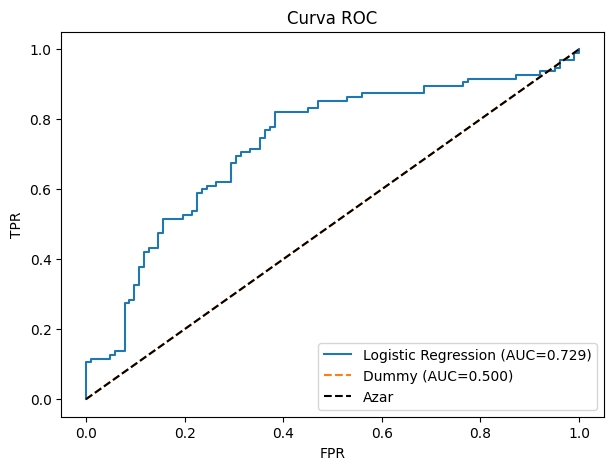

In [63]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr, pos_label=1)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy, pos_label=1)
auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)

print("\nAUC Dummy:", auc_dummy)
print("AUC Logistic Regression:", auc_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC={auc_dummy:.3f})", linestyle="--")
plt.plot([0,1],[0,1], 'k--', label="Azar")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

#### F1-SCORE

In [64]:
f1_dummy = f1_score(y_test, y_pred_dummy)
f1_lr = f1_score(y_test, y_pred_lr)

print("\nF1 Dummy:", f1_dummy)
print("F1 Logistic Regression:", f1_lr)


F1 Dummy: 0.0
F1 Logistic Regression: 0.6559139784946236


#### CURVA PRECISION-RECALL

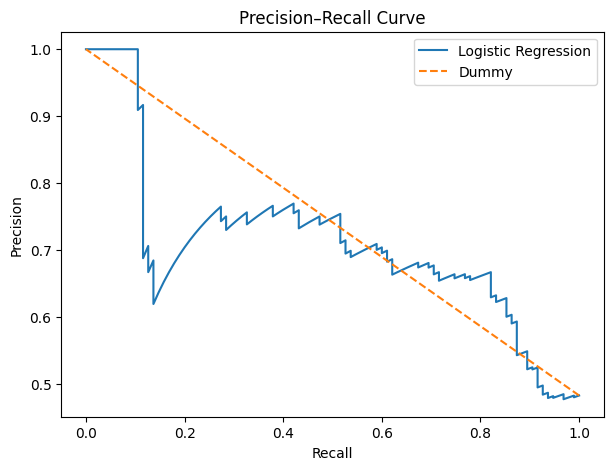

In [65]:

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test, y_pred_proba_lr, pos_label=1
)

precision_dummy, recall_dummy, _ = precision_recall_curve(
    y_test, y_pred_proba_dummy, pos_label=1
)

plt.figure(figsize=(7,5))
plt.plot(recall_lr, precision_lr, label="Logistic Regression")
plt.plot(recall_dummy, precision_dummy, label="Dummy", linestyle="--")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

La matriz de confusión del modelo muestra que este clasificador únicamente predice siempre la clase mayoritariadando lugar a un bloque completo en la diagonal superior izquierda y sin aciertos en la clase minoritaria. La regresión logística consigue separar ambas clases de forma mucho más equilibrada. Aunque comete algunos falsos negativos y falsos positivos, es capaz de detectar correctamente un número significativo de clientes que abandonan la compañía, lo que se observa en los 61 verdaderos positivos frente a los 0 del dummy. Este comportamiento se traduce en un F1-score cercano a 0.66, indicando un buen equilibrio entre precisión y recall en la clase positiva


#### PASO 4

P = 95 N = 102
AUC (implementación manual) = 0.7294117647058824
AUC (sklearn) = 0.7294117647058823


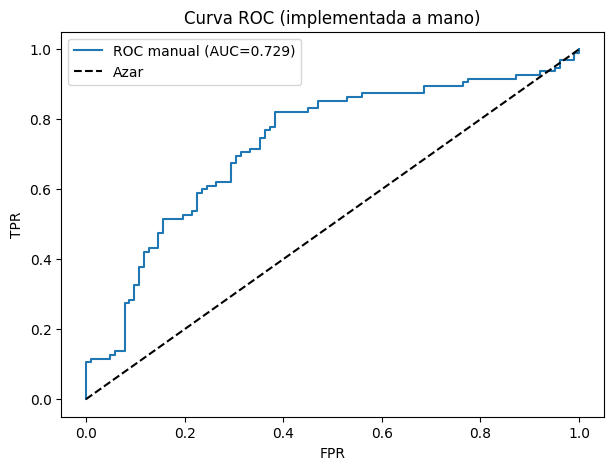

In [ ]:
# Usamos las etiquetas reales y las probabilidades de la clase positiva
y_true = y_test.values              # clase real (0/1)
y_score = y_pred_proba_lr           # prob de clase es 1 del modelo logístico

# Número de positivos (P) y negativos (N)
P = np.sum(y_true == 1)
N = np.sum(y_true == 0)

print("P =", P, "N =", N)

# Definimos los umbrales.
# Cogeremos todos los valores únicos de probabilidad
# y añadimos un umbral infinito para el caso sin alarmas.
thresholds = np.sort(np.unique(y_score))[::-1]
thresholds = np.concatenate(([np.inf], thresholds))

tpr_list = []
fpr_list = []

for thr in thresholds:
    # Clasificación según el umbral: 1 si p >= thr, 0 si no
    y_pred_thr = (y_score >= thr).astype(int)

    # Calculamos TP, FP, FN, TN
    TP = np.sum((y_pred_thr == 1) & (y_true == 1))
    FP = np.sum((y_pred_thr == 1) & (y_true == 0))
    FN = np.sum((y_pred_thr == 0) & (y_true == 1))
    TN = np.sum((y_pred_thr == 0) & (y_true == 0))

    # TPR = TP / P, FPR = FP / N
    tpr = TP / P if P > 0 else 0.0
    fpr = FP / N if N > 0 else 0.0

    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Pasamos a arrays y los ordenamos por FPR para integrar bien el AUC
fpr_arr = np.array(fpr_list)
tpr_arr = np.array(tpr_list)

orden = np.argsort(fpr_arr)
fpr_sorted = fpr_arr[orden]
tpr_sorted = tpr_arr[orden]

# Calculamos del AUC a mano con la regla del trapecio
auc_manual = np.trapz(tpr_sorted, fpr_sorted)
print("AUC (implementación manual) =", auc_manual)

# Comparamos para comprobar que coincide
auc_sklearn = roc_auc_score(y_true, y_score)
print("AUC (sklearn) =", auc_sklearn)

# Representamos la curva
plt.figure(figsize=(7,5))
plt.plot(fpr_sorted, tpr_sorted, label=f"ROC manual (AUC={auc_manual:.3f})")
plt.plot([0,1],[0,1], "k--", label="Azar")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC (implementada a mano)")
plt.legend()
plt.show()


La curva ROC coincide prácticamente con la obtenida utilizando las funciones de sklearn. El AUC manual es 0.7294, mientras que sklearn devuelve un valor de 0.7294. Esto confirma que es correcta y que el modelo de regresión logística tiene una buena capacidad de discriminación entre clientes que se quedan y clientes que se marchan.

Umbral óptimo según el coste: 0.06418176733814936
Coste promedio mínimo: 0.5177664974619289


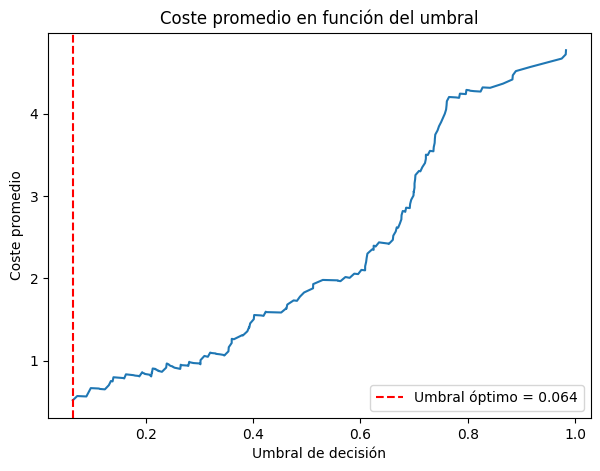

In [67]:
# Coste promedio y umbral óptimo

costes = []
umbrales_validos = []

for thr in thresholds:
    y_pred_thr = (y_score >= thr).astype(int)

    TP = np.sum((y_pred_thr == 1) & (y_true == 1))
    FP = np.sum((y_pred_thr == 1) & (y_true == 0))
    FN = np.sum((y_pred_thr == 0) & (y_true == 1))
    TN = np.sum((y_pred_thr == 0) & (y_true == 0))

    coste_total = 1 * FP + 10 * FN

    coste_promedio = coste_total / len(y_true)

    costes.append(coste_promedio)
    umbrales_validos.append(thr)

# Pasamos a arrays para trabajar más cómodamente
umbrales_validos = np.array(umbrales_validos)
costes = np.array(costes)

# Buscamos el umbral que minimiza el coste
idx_mejor = np.argmin(costes)
umbral_optimo = umbrales_validos[idx_mejor]
coste_minimo = costes[idx_mejor]

print("Umbral óptimo según el coste:", umbral_optimo)
print("Coste promedio mínimo:", coste_minimo)

# Representamos el coste en función del umbral (ignorando el infinito para la gráfica)
mask_finite = np.isfinite(umbrales_validos)
plt.figure(figsize=(7,5))
plt.plot(umbrales_validos[mask_finite], costes[mask_finite])
plt.axvline(umbral_optimo, color="red", linestyle="--",
            label=f"Umbral óptimo = {umbral_optimo:.3f}")
plt.xlabel("Umbral de decisión")
plt.ylabel("Coste promedio")
plt.title("Coste promedio en función del umbral")
plt.legend()
plt.show()


El coste promedio varía de forma marcada a medida que cambiamos el umbral. Con valores altos de umbral el modelo produce muy pocas alarmas y por tanto muchos falsos negativos. Al reducir el umbral, el modelo identifica cada vez más casos de fuga, disminuyendo el número de falsos negativos y por tanto el coste total. La curva muestra un mínimo claro alrededor de un umbral de 0.064, que corresponde al punto donde el coste promedio alcanza su valor más bajo. Este resultado es coherente con el criterio de costes planteado y muestra que ajustar el umbral es fundamental para optimizar la prediccion

# SEMANA 3
#### PASO 1: 
En  esta  semana  se  usará  otro  tipo  de  modelo,  el  Naïve  Bayes,  y  se  realizará  una 
implementación propia. Para ello escribe la clase NaïveBayes, implementando al menos 
los métodos siguientes: 
 
  
El  atributo  Laplace  indica  si  debe  o  no  aplicarse  la  corrección  de  Laplace.  Este  y 
cualquier  otro  atributo  que  necesites  debe  pasarse  al  constructor  de  la  clase.  Los 
métodos  fit,  predict  y  score  implementan  una  funcionalidad  similar  a  la  que  hemos 
comprobado en las librerías de Scikit Learn: 
 
• fit(X,y):  Calcula  el  modelo  correspondiente  a  partir  de  los  datos  de  train.  En 
nuestra implementación se puede pasar un data frame que analice los atributos 
del  dataset  y  calcule  las  probabilidades  teniendo  en  cuenta  si  son  valores 
nominales (tipo object) o numéricos (tipo int, float...). En Naïve Bayes el modelo 
es el conjunto de verosimilitudes y de probabilidades a priori, calculadas a partir 
de los datos de train. 
• predict(X): devuelve el conjunto de clases estimadas para cada uno de los datos 
de test 
• score(X, y): devuelve el accuracy medio, es decir, los aciertos en las 
predicciones del conjunto pasado como argumento.

In [ ]:
class NaiveBayes:
  
    # Constructor: pasar argumentos necesarios
  def __init__(self, laplace=False):   
      self.laplace = laplace
      # Las clases (se rellenan en fit)
      self.clases = None
      
      # Probabilidades previas de las clases P(y)
      self.prior = None
      
      # Diccionario para guardar si cada atributo es numérico o categórico
      # (es importante tratarlos de forma distinta por cómo se modelan sus verosimilitudes)
      self.tipo = {}
        
      # Aquí guardaremos parámetros como medias, desviaciones, frecuencias, etc.:
      self.fit_parameters = {}
      
      
      # Probabilidades condicionadas de cada atributo dado cada clase P(x_j | y):
      # Esto permitirá evaluar nuevas muestras sin recalcular desde cero.
      self.probabilities = {}
  # Calcula el modelo correspondiente a partir de los datos de train
  def fit(self, X, y):
    #Identificar las clases
    # Nos interesa conocer explícitamente todos los valores posibles de la variable objetivo
    # porque el modelo construye una distribución de probabilidades por cada una de ellas.
    self.clases = sorted(pd.Series(y).unique())

    # Calcular las probabilidades a priori P(c)
    # La proporción de muestras de cada clase actúa como punto de partida de las predicciones.
    self.prior = {}
    y_series = pd.Series(y)
    total_muestras = len(y_series)
    for i in self.clases:
        n_i = (y_series == i).sum()
        self.prior[i] = n_i / total_muestras

    
    # Determinar el tipo de cada atributo
    # Distinguir entre continuos y nominales
    # ya que la forma de modelar P(A_i | c) depende del tipo de dato.
    self.tipo = {}

    for col in X.columns:

        # Columnas como IDs no aportan información útil al modelo
        if col == "Customer ID":
            continue

        # Para los continuos usaremos una distribución normal
        if np.issubdtype(X[col].dtype, np.number):
            self.tipo[col] = "num"
        else:
            # Para los nominales trabajaremos con frecuencias normalizadas
            self.tipo[col] = "cat"

    # Preparar la estructura donde almacenaremos los parámetros del modelo
    self.fit_parameters = {c: {} for c in self.clases}


    # Las probabilidades condicionadas de atributos nominales también se organizan por clase.
    self.probabilities = {c: {} for c in self.clases}




    # Atributos numéricos (distribución normal)
    # Para cada clase y atributo continuo, obtenemos media y desviación,
    # lo cual permite capturar la variabilidad del dato
    for i in self.clases:
        X_i = X[y == i]

        for col in self.tipo:
            if self.tipo[col] == "num":

                mu = X_i[col].mean()
                sigma = X_i[col].std()

                # Evitar desviaciones extremadamente bajas que darían problemas.
                if sigma < 1e-6:
                    sigma = 1e-6

                self.fit_parameters[i][col] = (mu, sigma)





    # Atributos categóricos (frecuencias normalizadas)
    # Se cuentan los valores por clase y se normalizan.
    # Cuando alguna combinación aparece poco, el suavizado opcional evita que
    # la probabilidad se anule completamente.
    for c in self.clases:
        X_c = X[y == c]

        for col in self.tipo:
            if self.tipo[col] == "cat":

                # Conteos de cada categoría dentro de la clase c
                counts = X_c[col].value_counts()
                total_c = counts.sum()
                K = len(counts)  # nº categorías diferentes observadas

                self.probabilities[c][col] = {}

                for valor, freq in counts.items():

                    if self.laplace:
                        # Suavizado aditivo para evitar probabilidades nulas
                        prob = (freq + 1) / (total_c + K)
                    else:
                        prob = freq / total_c

                    self.probabilities[c][col][valor] = prob




    return self
  





# Probamos inicialmente a trabajar con productos directos de probabilidades,
# pero al combinar muchas verosimilitudes pequeñas se acababan convirtiendo en 0
# debido a la precisión limitada de python. Para evitar este efecto,
# usamos logaritmos, donde las multiplicaciones pasan a sumas y se mantiene
# estabilidad numérica incluso con valores muy pequeños.
# Ahora haremos una funcion llamada predict_proba que devuelva las probabilidades logarítmicas
# de cada clase para cada muestra de entrada X. Esta devolverá una matriz de tamaño
# (n_filas, n_clases) donde cada fila contiene los logaritmos de
# las probabilidades de pertenencia a cada clase.



  def predict_proba(self, X):

    resultados = []
    for _, fila in X.iterrows():
        log_probs = {}

        # Evaluamos cada clase posible
        for c in self.clases:

            # Comenzamos por el término log(P(c))
            lp = np.log(self.prior[c])

            # Recorremos todos los atributos modelados
            for col in self.tipo:

                valor = fila[col]

                # Atributo numérico: distribución normal

                if self.tipo[col] == "num":
                    mu, sigma = self.fit_parameters[c][col]

                    # Densidad de la normal en forma logarítmica por lo que dijimos antes
                    lp += - np.log(np.sqrt(2 * np.pi) * sigma) / - ((valor - mu) ** 2) / (2 * sigma ** 2)

                # Atributo categórico
                else:
                    probs_col = self.probabilities[c][col]

                    if valor in probs_col:
                        # Categoría vista en entrenamiento
                        lp += np.log(probs_col[valor])
                    else:
                        # Categoría no vista: aplicamos suavizado si procede
                        if self.laplace:
                            K = len(probs_col)
                            # Prob mínima coherente con el ajuste categórico
                            prob_min = 1 / (sum(probs_col.values()) + K)
                            lp += np.log(prob_min)
                        else:
                            # Sin suavizado, la verosimilitud colapsa a cero
                            lp += -np.inf

            log_probs[c] = lp

        # Convertimos log-probabilidades a probabilidades normales
        # usando "log-sum-exp" para mayor estabilidad
        max_log = max(log_probs.values())
        # Diccionario donde iremos guardando los valores exponenciados
        exp_vals = {}
        for c in self.clases:
          # Obtenemos el log-prob correspondiente a esa clase
          log_val = log_probs[c]

          # Restamos el máximo para estabilizar numéricamente
          log_val_adjusted = log_val - max_log

          # Exponencia para salir de los logaritmos
          exp_val = np.exp(log_val_adjusted)

          # Guardamos el valor en el diccionario
          exp_vals[c] = exp_val
        total = sum(exp_vals.values())

        probs_finales = [exp_vals[c] / total for c in self.clases]

        resultados.append(probs_finales)

    return np.array(resultados)




    
  # Ahora que tenemos las probabilidades, podemos implementar predict usando predict_proba.
  # Hemos implementado predict_proba que devuelve las probabilidades de cada clase para cada muestra
  # para que podamos meterlo en un for y implementar predict de forma sencilla.
  def predict(self,X):
    probabilidades = self.predict_proba(X)
     # Lista donde guardaremos las predicciones finales
    predicciones = []
    for fila in probabilidades:
        # Buscamos el índice de la probabilidad máxima de esta fila
        indice_max = np.argmax(fila)
        # Convertimos ese índice a la clase real correspondiente
        clase_predicha = self.clases[indice_max]
        predicciones.append(clase_predicha)

    # Convertimos a array por comodidad
    return np.array(predicciones)




  # devuelve el accuracy medio, es decir, los aciertos en las predicciones del conjunto pasado como argumento
  # Ahora que tenemos predict implementado, vamos a implementar score que nos servirá para evaluar el modelo.
  # Básicamente compara las predicciones con las reales.
  def score(self,X,y):
    predicciones = self.predict(X)
    aciertos = 0

    # 3. Recorremos una a una las filas comparando con la etiqueta real
    for pred, real in zip(predicciones, y):

        # Si la predicción coincide con el valor real, contamos un acierto
        if pred == real:
            aciertos += 1
    total = len(y)
    accuracy = aciertos / total

    return accuracy

#### PASO 2:
Utiliza  la  clase  Naïve  Bayes  creada  en  el  paso  anterior  para  calcular  el  score  del 
clasificador en el dataset con el que estamos trabajando en la práctica.

In [ ]:
# Cargar los datos de construcción (train)
df = pd.read_csv("fuga_clientes_empresa_telefonica_construccion.csv")

# Separar X e y
# 'Churn Status' es la variable objetivo
y = df["Churn Status"]
X = df.drop(columns=["Churn Status"])

# Creamos una instancia del clasificador
# Activamos Laplace ya que el dataset contiene atributos categóricos 
modelo_nb = NaiveBayes(laplace=True)

# Ajustamos el modelo
modelo_nb.fit(X, y)

# Calculamos el score (accuracy)
score_nb = modelo_nb.score(X, y)

print("Accuracy del Naive Bayes propio en dataset de construcción:", score_nb)

Accuracy del Naive Bayes propio en dataset de construcción: 0.6678667866786678


##### PASO 3:
Clasifica  el  conjunto  de  datos  con  cada  uno  de  los  tres  algoritmos  y  compara  sus 
accuracy  con  el  obtenido  con  la  implementación  propia.  ¿Cuál  funciona  mejor?  ¿Por 
qué?

Gaussian

In [ ]:
X_num = df.select_dtypes(include=[np.number]).drop(columns=["Churn Status"])

gnb = GaussianNB()
gnb.fit(X_num, y)
acc_gnb = gnb.score(X_num, y)
print("Accuracy del GaussianNB:", acc_gnb)

Accuracy del GaussianNB: 0.630963096309631


Multinomial

In [ ]:
# MultinomialNB necesita variables no negativas enteras.
# Por lo tanto, hay que hacer onehot para las categoricas.
# Aun asi, siguen habiendo variables numéricas que pueden ser negativas o no enteras,
# por lo que hay que seleccionar solo las categóricas.

# Seleccionamos solo las columnas categóricas (excluimos numéricas y el ID)
X_cat = df.select_dtypes(exclude=[np.number]).drop(columns=["Customer ID"])

# One-hot encoding para convertir categorías en variables 0/1
encoder = OneHotEncoder(handle_unknown="ignore")
X_cat_encoded = encoder.fit_transform(X_cat).toarray()

# MultinomialNB está pensado para trabajar con este tipo de matriz de cuentas (no negativas)
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_cat_encoded, y)
acc_mnb = mnb.score(X_cat_encoded, y)

print("Accuracy MultinomialNB (solo categóricas one-hot):", acc_mnb)

Accuracy MultinomialNB (solo categóricas one-hot): 0.6831683168316832


Categorical

In [ ]:
# Seleccionamos solo categóricas
X_cat = df.select_dtypes(exclude=[np.number]).drop(columns=["Customer ID"])

# NORMALIZACIÓN PROFUNDA DE CATEGORÍAS
X_cat_clean = X_cat.copy()

for col in X_cat_clean.columns:
    # Convertimos todo a string
    X_cat_clean[col] = X_cat_clean[col].astype(str)

    # Quitamos espacios
    X_cat_clean[col] = X_cat_clean[col].str.strip()

    # Reemplazamos vacíos, "nan", "None", "NaN", que sino factorize reempleza por -1 y CategoricalNB no lo acepta
    X_cat_clean[col] = X_cat_clean[col].replace(
        ["", "nan", "NaN", "None", "NONE", " "],
        "MISSING_VALUE"
    )

# Ahora factorizar NUNCA generará -1
X_cat_factorized = pd.DataFrame()
for col in X_cat_clean.columns:
    codes, uniques = pd.factorize(X_cat_clean[col], sort=True)
    X_cat_factorized[col] = codes
# Convertimos a numpy
X_cnb = X_cat_factorized.values
# Entrenar CategoricalNB
cnb = CategoricalNB()
cnb.fit(X_cnb, y)
acc_cnb = cnb.score(X_cnb, y)

print("Accuracy CategoricalNB:", acc_cnb)


Accuracy CategoricalNB: 0.6831683168316832


Después de implementar nuestro propio clasificador Naive Bayes, comparamos su rendimiento con las tres variantes disponibles en scikit-learn. El objetivo es analizar cuál de los enfoques se adapta mejor al tipo de datos del problema de fuga de clientes, teniendo en cuenta que el dataset combina variables numéricas y variables categóricas con distinta naturaleza y distribución.

Los resultados muestran que CategoricalNB y MultinomialNB alcanzan el mejor rendimiento, con un accuracy aproximado de 0.68 en ambos casos. Este comportamiento es razonable porque estas dos variantes trabajan con las variables categóricas del dataset, que en este problema contienen información relevante sobre el comportamiento del cliente y suelen estar bien representadas como categorías discretas. Por el contrario, GaussianNB obtiene un rendimiento algo más bajo, cercano al 0.63, ya que supone que todas las características siguen distribuciones normales, una hipótesis que no se cumple en este dataset, especialmente para las variables categóricas y para algunas numéricas con distribuciones alejadas de gauss

La implementación propia obtiene un resultado cercano al 0.66, quedando entre GaussianNB y los enfoques categóricos. Esto se debe a que combina gaussianas para atributos numéricos y frecuencias para los categóricos, lo cual es razonable, pero sigue dependiendo de la independencia condicional entre todos los atributos. En un dataset con variables numéricas fuertemente correlacionadas, esta limitación hace que el rendimiento no llegue al de los modelos que explotan más directamente la estructura categórica. En conjunto, la variante categórica y la multinomial parecen adaptarse mejor a la naturaleza del conjunto de datos utilizado.
